In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

Coleta de Dados

In [3]:
ticker = "PETR4.SA"

df = yf.download(ticker, start="2015-01-01")

df = df[['Close']]

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,PETR4.SA
Date,
2015-01-02,2.493752
2015-01-05,2.280610
2015-01-06,2.206011
2015-01-07,2.309918
2015-01-08,2.459116


Visualização

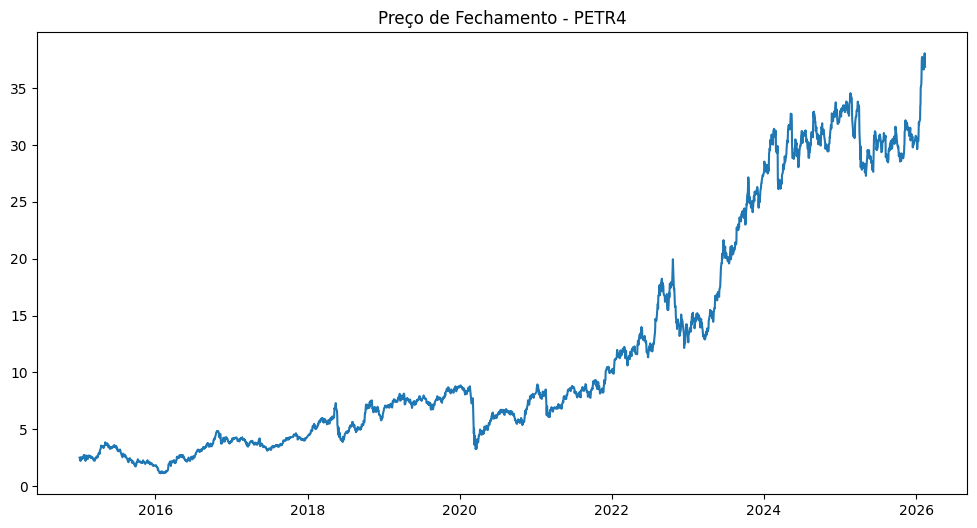

In [4]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("Preço de Fechamento - PETR4")
plt.show()

Normalização

In [5]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)
scaled_data[:5]

array([[0.03719488],
       [0.03142823],
       [0.02940992],
       [0.03222116],
       [0.03625781]])

Criar janela temporal (60 dias)

In [6]:
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data, 60)

print(X.shape, y.shape)

(2707, 60) (2707,)


Criar janela temporal (60 dias)

In [7]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# reshape
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (2165, 60, 1)
Teste: (542, 60, 1)


Ajustar formato para LSTM

In [8]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Formato final treino:", X_train.shape)

Formato final treino: (2165, 60, 1)


Criar Modelo LSTM

In [10]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(60,1)),
    Dropout(0.2),
    
    LSTM(64),
    Dropout(0.2),
    
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,033 (453.25 KB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

Treinar

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 0.0035 - val_loss: 0.0028
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 6.3898e-04 - val_loss: 0.0011
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 6.2559e-04 - val_loss: 0.0010
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - loss: 7.0138e-04 - val_loss: 9.9353e-04
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 5.3547e-04 - val_loss: 0.0012
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 5.3764e-04 - val_loss: 0.0011
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 4.7967e-04 - val_loss: 8.3719e-04
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 4.3642e-04 - val_loss: 0.0016
Epoch 9/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 4.3037e-04 - val_loss: 7.2649e-04
Epoch 10/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 4.3038e-04 - val_loss: 0.0028
Epoch 11/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - loss: 4.1199e-04 - val_loss: 0.0013
Epoch 12

Gerar Previsão

In [12]:
y_pred = model.predict(X_test)


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


Escala

In [13]:
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_real = scaler.inverse_transform(y_pred.reshape(-1,1))


Calculo Metricas

In [14]:
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 0.7241693757117015
RMSE: 0.9519045889549211
MAPE: 2.3523708376942287


Grafico

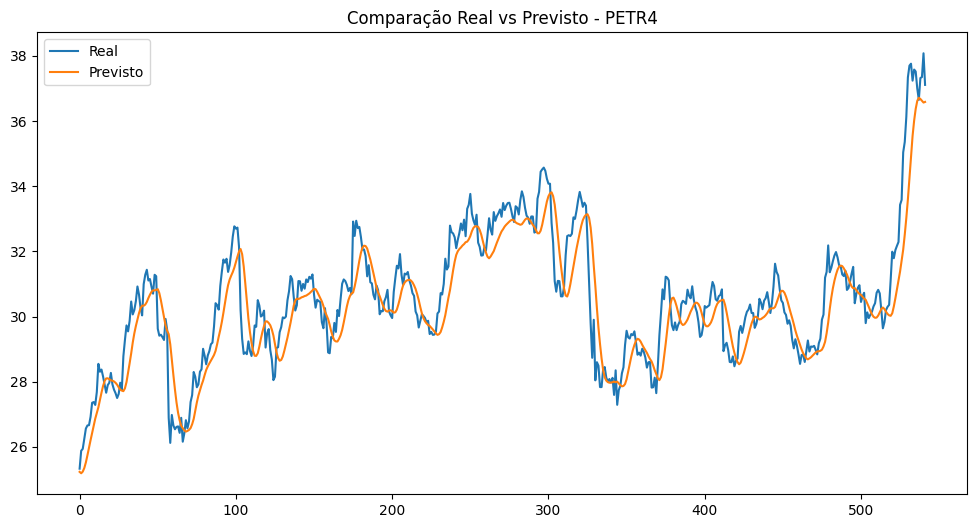

In [15]:
plt.figure(figsize=(12,6))
plt.plot(y_test_real, label="Real")
plt.plot(y_pred_real, label="Previsto")
plt.legend()
plt.title("Comparação Real vs Previsto - PETR4")
plt.show()

O modelo LSTM apresentou bom desempenho na previsão do preço de fechamento da ação PETR4, obtendo MAE de aproximadamente R$0,72, RMSE de R$0,95 e MAPE de 2,35%. Os resultados indicam que a rede neural foi capaz de capturar padrões temporais relevantes da série histórica, apresentando baixo erro médio e boa generalização nos dados de teste.

In [16]:
model.save("modelo_lstm_petr4.h5")
print("Modelo salvo com sucesso!")


Modelo salvo com sucesso!


teste carga modelo

In [19]:
from tensorflow.keras.models import load_model

modelo_carregado = load_model("modelo_lstm_petr4.h5")
print("Modelo carregado com sucesso!")

import joblib
joblib.dump(scaler, "scaler_petr4.save")

Modelo carregado com sucesso!


['scaler_petr4.save']

['scaler_petr4.save']